# Unrotated $X_1 Z_2$ Joint Lattice Surgery Measurement

Mixed-Pauli joint measurement on the **unrotated** surface code, **no bend**.

In [21]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle, Rectangle
import matplotlib.patches as mpatches

from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode, UnrotatedMultiPatchCoupler)
from lightstim.ir.qec_system import QECSystem
from lightstim.protocols.routed_multi_patch_ls import (
    logical_pauli_product_vector, _coupler_on_active_stabilizer_uids)
from lightstim.utils.tableau_utils import stabilizers_to_symplectic


def gf2_rank(rows):
    M = np.array([r.copy() for r in rows], np.uint8); r = 0
    for c in range(M.shape[1]):
        piv = next((k for k in range(r, M.shape[0]) if M[k, c]), None)
        if piv is None:
            continue
        M[[r, piv]] = M[[piv, r]]
        for k in range(M.shape[0]):
            if k != r and M[k, c]:
                M[k] ^= M[r]
        r += 1
    return r

def in_span(rows, t):
    return gf2_rank(list(rows) + [t]) == gf2_rank(list(rows))


def build_xz(d=3):
    # XX merge of two standard patches, then transversal-H on p2 -> X1*Z2
    system = QECSystem()
    system.add_patch(UnrotatedSurfaceCode(distance=d), name='p1')
    system.add_patch(UnrotatedSurfaceCode(distance=d), name='p2', offset=(10, 0))
    system.register_coupler(UnrotatedMultiPatchCoupler(), ['p1', 'p2'], 'c',
                            path_axis='vertical', center_axis=7.0)
    system.activate_coupler('c')
    N = system.num_qubits
    recs = [system.stabilizers[u] for u in sorted(_coupler_on_active_stabilizer_uids(system, 'c'))]
    S = stabilizers_to_symplectic(system, recs, N)
    p2_data = {q for q in range(N)
               if system.index_to_owner_map.get(q) == 'p2' and q in system.data_indices}
    H = S.copy()
    for q in p2_data:                     # transversal Hadamard on p2 data
        H[:, [q, N + q]] = H[:, [N + q, q]]
    def hconj(v):
        v = v.copy()
        for q in p2_data:
            v[[q, N + q]] = v[[N + q, q]]
        return v
    return system, recs, H, N, p2_data, hconj


system, recs, H, N, p2_data, hconj = build_xz(3)
print('built: 2 patches + coupler, transversal H on p2')

built: 2 patches + coupler, transversal H on p2


In [22]:
# ---- verify the four hard requirements ----
ndata = len(system.data_indices)
rank = gf2_rank(list(H))
bad = sum(
    1 for i in range(len(H)) for j in range(i + 1, len(H))
    if int((H[i][:N] & H[j][N:]).sum() + (H[i][N:] & H[j][:N]).sum()) % 2)
mixed = [row for row in H if row[:N].sum() and row[N:].sum()]
anyY = sum(1 for row in H if int((row[:N] & row[N:]).sum()))

vXZ = hconj(logical_pauli_product_vector(system, ['p1', 'p2'], ['X', 'X'])[0])   # H(X1 X2)=X1 Z2
joint = in_span(H, vXZ)
singles = {f'{p}{t}': in_span(H, hconj(logical_pauli_product_vector(system, [p], [t])[0]))
           for p, t in [('p1', 'X'), ('p2', 'X'), ('p2', 'Z')]}

print(f'(1) #data - rank = {ndata} - {rank} = {ndata - rank}   (expect 1)')
print(f'    all stabilizers commute        : {bad == 0}  (anticommuting pairs = {bad})')
print(f'(2) joint  X1*Z2  measured         : {joint}')
print(f'    any single X1/X2/Z2 measured   : {any(singles.values())}   {singles}')
print(f'(3) check types present            : pure-X, pure-Z, and MIXED={len(mixed)}')
print(f'(4) MIXED domain-wall checks       : {len(mixed)}   checks-with-Y (twist) = {anyY}')

PASS = (ndata - rank == 1 and bad == 0 and joint and not any(singles.values())
        and len(mixed) > 0 and anyY == 0)
print(f'\nALL REQUIREMENTS PASS = {PASS}')
assert PASS

(1) #data - rank = 38 - 37 = 1   (expect 1)
    all stabilizers commute        : True  (anticommuting pairs = 0)
(2) joint  X1*Z2  measured         : True
    any single X1/X2/Z2 measured   : False   {'p1X': False, 'p2X': False, 'p2Z': False}
(3) check types present            : pure-X, pure-Z, and MIXED=5
(4) MIXED domain-wall checks       : 5   checks-with-Y (twist) = 0

ALL REQUIREMENTS PASS = True


In [23]:
# ---- the two logical operators being measured ----
p1 = system.patches['p1'][0]
p2 = system.patches['p2'][0]
cp = system.coupler_patches['c']
p2coords = {tuple(p2.qubit_coords[q]) for q in p2.data_indices}
Hp = {'X': 'Z', 'Z': 'X'}.get

X1_support = sorted(tuple(p1.qubit_coords[q]) for q in p1.logical_ops_x['pauli'])
# Z2 (measured) = transversal-H(X2): lives on p2's logical-X support, carrying Z
Z2_support = sorted(tuple(p2.qubit_coords[q]) for q in p2.logical_ops_x['pauli'])
print(f'MEASURED  X-bar_1  =  X on p1 @ {X1_support}')
print(f'MEASURED  Z-bar_2  =  Z on p2 @ {Z2_support}')
print()

mixed_checks = []
for s in cp.stabilizers:
    newp = {c: (Hp(P) if c in p2coords else P) for c, P in s['pauli'].items()}
    if {'X', 'Z'} <= set(newp.values()):
        xs = sorted(c for c, P in newp.items() if P == 'X')
        zs = sorted(c for c, P in newp.items() if P == 'Z')
        mixed_checks.append((s['syn_coord'], newp, xs, zs))

print(f'{len(mixed_checks)} MIXED domain-wall stabilizers (the standard unrotated mixed check):')
for syn, _, xs, zs in mixed_checks:
    print(f'  @ {syn}:   X @ {xs}    Z @ {zs}')

MEASURED  X-bar_1  =  X on p1 @ [(0.0, 0.0), (0.0, 2), (0.0, 4)]
MEASURED  Z-bar_2  =  Z on p2 @ [(10.0, 0.0), (10.0, 2), (10.0, 4)]

5 MIXED domain-wall stabilizers (the standard unrotated mixed check):
  @ (9.0, 0.0):   X @ [(8.0, 0.0), (9.0, 1.0)]    Z @ [(10.0, 0.0)]
  @ (9.0, 2.0):   X @ [(8.0, 2.0), (9.0, 1.0), (9.0, 3.0)]    Z @ [(10.0, 2.0)]
  @ (9.0, 4.0):   X @ [(8.0, 4.0), (9.0, 3.0)]    Z @ [(10.0, 4.0)]
  @ (10.0, 1):   X @ [(10.0, 0), (10.0, 2), (11.0, 1)]    Z @ [(9.0, 1)]
  @ (10.0, 3):   X @ [(10.0, 2), (10.0, 4), (11.0, 3)]    Z @ [(9.0, 3)]


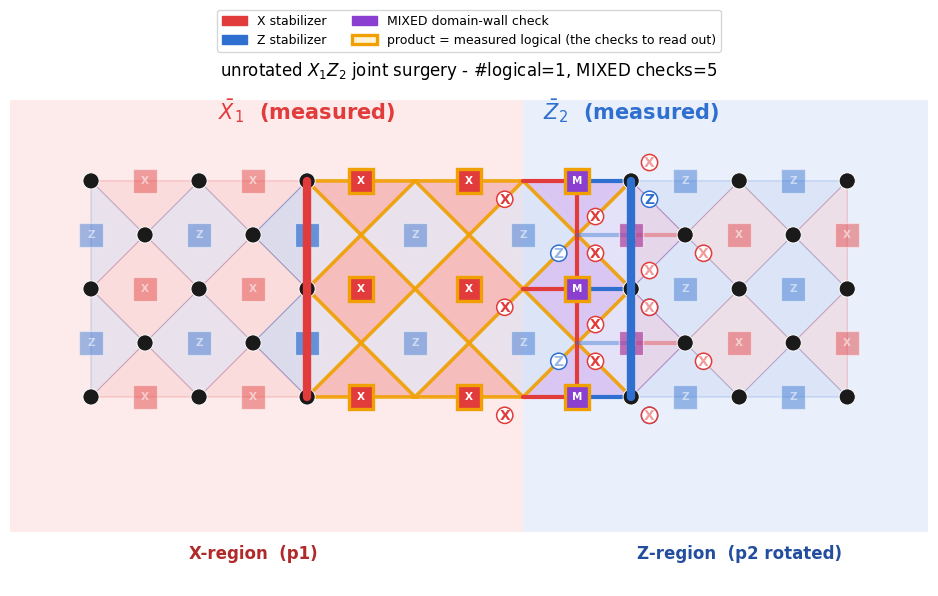

In [24]:
# ---- visualize the construction; highlight the stabilizers whose product = the measured logical ----
from lightstim.utils.linear_algebra import solve_linear_decomposition
p1 = system.patches['p1'][0]
COL = {'X': '#e23b3b', 'Z': '#2f6fd0', 'MIXED': '#8b3fd0'}; FILL = {'X': '#f6b8b8', 'Z': '#b8cdf0', 'MIXED': '#d9c2f2'}
GOLD = '#f0a000'

checks = []
for patch, name in [(p1, 'p1'), (p2, 'p2')]:
    for s in patch.stabilizers:
        pl = {tuple(patch.qubit_coords[q]): (Hp(P) if name == 'p2' else P) for q, P in s['pauli'].items()}
        checks.append((s['syn_coord'], pl, 'X' if set(pl.values()) == {'X'} else 'Z'))
for s in cp.stabilizers:
    pl = {c: (Hp(P) if c in p2coords else P) for c, P in s['pauli'].items()}
    ts = set(pl.values()); checks.append((s['syn_coord'], pl, 'MIXED' if {'X','Z'} <= ts else ('X' if ts == {'X'} else 'Z')))

_xr1 = max(p1.qubit_coords[q][0] for q in p1.data_indices)
x1c = sorted(tuple(p1.qubit_coords[q]) for q in p1.data_indices if p1.qubit_coords[q][0] == _xr1)
z2c = sorted(tuple(p2.qubit_coords[q]) for q in p2.logical_ops_x['pauli'])

_dc = sorted({c for _, pl, _ in checks for c in pl}); _ci = {c: i for i, c in enumerate(_dc)}; _nd = len(_dc)
def _sv(pl):
    v = np.zeros(2 * _nd, np.uint8)
    for c, P in pl.items():
        if P in ('X', 'Y'): v[_ci[c]] ^= 1
        if P in ('Z', 'Y'): v[_nd + _ci[c]] ^= 1
    return v
_co, _dep, _ = solve_linear_decomposition(
    basis=np.array([_sv(pl) for _, pl, _ in checks], np.uint8),
    targets=_sv({**{c: 'X' for c in x1c}, **{c: 'Z' for c in z2c}}).reshape(1, -1), reduce_weight=True)
HL = set(np.where(_co[0])[0]) if _dep[0] else set()

fig, ax = plt.subplots(figsize=(13, 6))
allc = [c for _, p, _ in checks for c in p]; x0, x1 = min(c[0] for c in allc) - 1.5, max(c[0] for c in allc) + 1.5
ax.add_patch(Rectangle((x0, -1.5), 8.0 - x0, 8, facecolor='#fdeaea', ec='none', zorder=0))
ax.add_patch(Rectangle((8.0, -1.5), x1 - 8.0, 8, facecolor='#e9effb', ec='none', zorder=0))
ax.text(3, 7.0, 'X-region  (p1)', ha='center', color='#b02a2a', fontsize=12, fontweight='bold')
ax.text(12, 7.0, 'Z-region  (p2 rotated)', ha='center', color='#234e9e', fontsize=12, fontweight='bold')

for i, (syn, pauli, t) in enumerate(checks):
    hl = i in HL; a = 0.9 if hl else 0.28
    pts = list(pauli)
    if len(pts) >= 3:
        cx, cy = np.mean([p[0] for p in pts]), np.mean([p[1] for p in pts])
        order = sorted(pts, key=lambda p: np.arctan2(p[1] - cy, p[0] - cx))
        ax.add_patch(Polygon(order, closed=True, facecolor=FILL[t], edgecolor=(GOLD if hl else COL[t]),
                     lw=(2.6 if hl else 0.7), alpha=a, zorder=(3 if hl else 2)))
    elif len(pts) == 2:
        (a1, b1), (c1, d1) = pts
        ax.plot([a1, syn[0], c1], [b1, syn[1], d1], color=(GOLD if hl else COL[t]), lw=(8 if hl else 6),
                alpha=(0.7 if hl else 0.28), solid_capstyle='round', zorder=(3 if hl else 2))
    if t == 'MIXED':
        for c, P in pauli.items():
            ax.plot([syn[0], c[0]], [syn[1], c[1]], color=COL[P], lw=3, zorder=5, alpha=(1 if hl else 0.4), solid_capstyle='round')
            ox = 0.34 if c[0] >= syn[0] else -0.34; oy = 0.34 if c[1] >= syn[1] else -0.34
            ax.text(c[0] + ox, c[1] + oy, P, color=COL[P], fontsize=10, fontweight='bold', ha='center', va='center',
                    zorder=9, alpha=(1 if hl else 0.5), bbox=dict(boxstyle='circle,pad=0.08', fc='white', ec=COL[P], lw=1.1))
    ax.add_patch(Rectangle((syn[0] - 0.22, syn[1] - 0.22), 0.44, 0.44, facecolor=COL[t],
                 edgecolor=(GOLD if hl else 'white'), lw=(2.4 if hl else 0.9), zorder=6, alpha=(1 if hl else 0.45)))
    ax.text(syn[0], syn[1], 'M' if t == 'MIXED' else t, ha='center', va='center', fontsize=7.5,
            color='white', fontweight='bold', zorder=7, alpha=(1 if hl else 0.55))

for patch in (p1, p2):
    for q in patch.data_indices:
        ax.add_patch(Circle(tuple(patch.qubit_coords[q]), 0.15, facecolor='#1a1a1a', edgecolor='white', lw=0.7, zorder=8))
ax.plot([c[0] for c in x1c], [c[1] for c in x1c], color=COL['X'], lw=6, zorder=10, solid_capstyle='round')
ax.plot([c[0] for c in z2c], [c[1] for c in z2c], color=COL['Z'], lw=6, zorder=10, solid_capstyle='round')
ax.text(x1c[0][0], -1.15, r'$\bar X_1$  (measured)', color=COL['X'], fontsize=15, fontweight='bold', ha='center')
ax.text(z2c[0][0], -1.15, r'$\bar Z_2$  (measured)', color=COL['Z'], fontsize=15, fontweight='bold', ha='center')
handles = [mpatches.Patch(color=COL['X'], label='X stabilizer'), mpatches.Patch(color=COL['Z'], label='Z stabilizer'),
           mpatches.Patch(color=COL['MIXED'], label='MIXED domain-wall check'),
           mpatches.Patch(facecolor='#fff3d6', edgecolor=GOLD, lw=2.4, label='product = measured logical (the checks to read out)')]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.16), ncol=2, fontsize=9)
ax.set_xlim(x0, x1); ax.set_ylim(-1.8, 7.5); ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
ax.set_title(f'unrotated $X_1Z_2$ joint surgery - #logical={ndata-rank}, MIXED checks={len(mixed)}', fontsize=12)
plt.tight_layout(); plt.show()

---
## Circuit-level syndrome extraction (measures the mixed stabilizers)

The circuit measures the **same 5 mixed domain-wall checks** shown above. `p2` is rotated
by **re-typing its stabilizers** — swap $X\leftrightarrow Z$ on every `p2`-data Pauli:
`p2`'s own checks become the dual (still pure $X/Z$), and the coupler checks spanning the
seam become genuine **MIXED** checks. The extraction block measures each MIXED check with
an X-basis syndrome ancilla (`CNOT(ancilla→data)` on the X-side qubits,
`CZ(ancilla,data)` on the Z-side), so the circuit **literally measures the mixed
stabilizers** — no transversal-$H$ trick.

**Acceptance:** `assert_dem_valid` + `assert_noiseless`, **plus** a check via
`stim.Circuit.detecting_regions()` that detectors really measure *instantaneous* mixed
data checks ($X$ and $Z$ on different data qubits at the same tick).

In [25]:
from lightstim.qec_code.surface_code.unrotated import UnrotatedSurfaceCodeExtractionBlock
from lightstim.ir.builder import CircuitBuilder
from lightstim.ir.tracker import SyndromeTracker


def build_mixed_circuit(rounds=2, init_basis='Z', coupler_init='X'):
    system = QECSystem()
    system.add_patch(UnrotatedSurfaceCode(distance=3), name='p1')
    system.add_patch(UnrotatedSurfaceCode(distance=3), name='p2', offset=(10, 0))
    system.register_coupler(UnrotatedMultiPatchCoupler(), ['p1', 'p2'], 'c',
                            path_axis='vertical', center_axis=7.0)
    cp = system.coupler_patches['c']
    p2_data = {q for q in system.data_indices if system.index_to_owner_map.get(q) == 'p2'}
    SW = {'X': 'Z', 'Z': 'X'}
    for s in system.stabilizers:            # rotate p2 by re-typing: swap X<->Z on p2-data
        s['pauli'] = {q: (SW[P] if q in p2_data else P) for q, P in s['pauli'].items()}
        ts = set(s['pauli'].values())
        s['type'] = 'MIXED' if {'X', 'Z'} <= ts else ('X' if ts == {'X'} else 'Z')

    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    builder.write_coordinates()
    nc = {q: init_basis for q in system.data_indices if system.index_to_owner_map[q] != 'c'}
    builder.initialize(init_dict=nc, n=system.num_qubits)
    builder.apply_syndrome_extraction(
        circuit_chunk=UnrotatedSurfaceCodeExtractionBlock(system).circuit, rounds=rounds)
    builder.activate_coupler('c')
    builder.initialize(init_dict={system.local_to_global_map['c'][q]: coupler_init
                                  for q in cp.data_indices}, n=system.num_qubits)
    builder.apply_syndrome_extraction(
        circuit_chunk=UnrotatedSurfaceCodeExtractionBlock(system).circuit, rounds=rounds)
    builder.apply_data_readout(final_measurements=nc)
    return builder.circuit, system


circuit, circ_system = build_mixed_circuit(rounds=2)
print(f'circuit: qubits={circuit.num_qubits} detectors={circuit.num_detectors} '
      f'observables={circuit.num_observables}')
print(f'active MIXED stabilizers measured by the circuit: {len(circ_system.active_stabilizers_mixed)}')

circuit: qubits=75 detectors=106 observables=1
active MIXED stabilizers measured by the circuit: 5


In [26]:
# ---- acceptance: DEM valid + noiseless + really measures the mixed checks ----
dem = circuit.flattened().detector_error_model(decompose_errors=True)
dem_ok = (dem.num_detectors == circuit.num_detectors and dem.num_observables == circuit.num_observables)
dets, obs = circuit.compile_detector_sampler(seed=42).sample(shots=200, separate_observables=True)
noiseless_ok = (not dets.any()) and (not obs.any())

# does the circuit measure GENUINE instantaneous mixed data checks (X & Z on different
# data qubits at the same tick) -- i.e. is it really using the domain-wall stabilizers?
DATA = set(circ_system.data_indices)
n_mixed = 0
for det, ticks in circuit.detecting_regions().items():
    for ps in ticks.values():
        xs = [i for i in range(len(ps)) if ps[i] == 1 and i in DATA]
        zs = [i for i in range(len(ps)) if ps[i] == 3 and i in DATA]
        ys = [i for i in range(len(ps)) if ps[i] == 2 and i in DATA]
        if xs and zs and not ys:
            n_mixed += 1
            break

print(f'DEM valid                              : {dem_ok}')
print(f'noiseless 200 shots: det={int(dets.sum())}, logical_errors={int(obs.sum())}')
print(f'detectors measuring an instantaneous MIXED data check: {n_mixed}')
print(f'  (> 0  =>  the circuit really measures the domain-wall mixed stabilizers)')
print(f'\nCIRCUIT ACCEPTANCE PASS = {dem_ok and noiseless_ok and n_mixed > 0}')
assert dem_ok and noiseless_ok and n_mixed > 0

DEM valid                              : True
noiseless 200 shots: det=0, logical_errors=0
detectors measuring an instantaneous MIXED data check: 5
  (> 0  =>  the circuit really measures the domain-wall mixed stabilizers)

CIRCUIT ACCEPTANCE PASS = True


---
## Circuit diagram (`detslice-with-ops-svg`)

Detector-slice view of the syndrome-extraction circuit with operations overlaid
(red = X stabilizer, blue = Z stabilizer).  `p1` (left) and the rotated `p2` (right)
are merged through the coupler; the mixed domain-wall checks live at the seam.

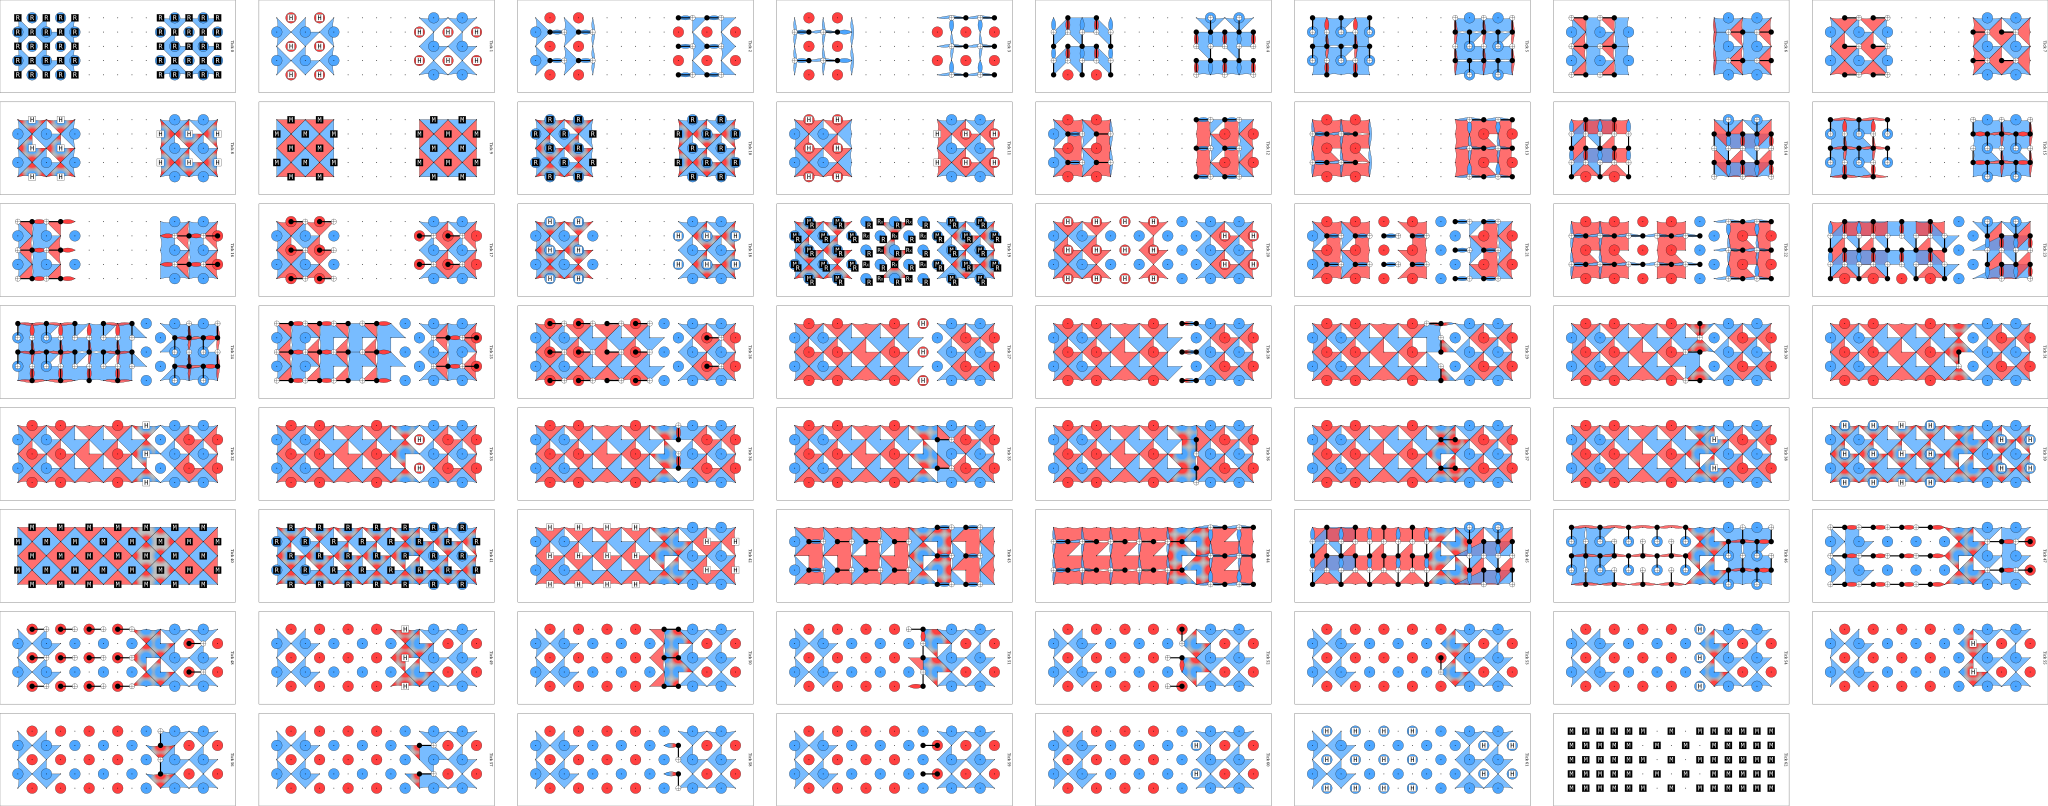

In [27]:
circuit.diagram("detslice-with-ops-svg")

---
## Logical error rate vs physical error rate $p$

Sweep the **circuit-level** noise strength $p$ for code distances $d\in\{3,5,7\}$ (with $d$
syndrome-extraction rounds before and after the merge), build the detector-error-model,
decode with **MWPM** (PyMatching), and estimate the logical error rate of the joint
$X_1Z_2$ measurement.

In [28]:
# ---- LER vs p:  build noisy circuits + adaptive MWPM decode ----
import pymatching
from lightstim.noise.config import NoiseConfig


def build_mixed_circuit_noisy(d=3, p=1e-3, rounds=None, init_basis='Z', coupler_init='X',
                              noise_model='circuit_level'):
    """Distance-d  X1*Z2  joint-measurement circuit with circuit-level noise p.
    Same construction as build_mixed_circuit above, but distance-parameterized
    (offset_x = 2d+4, center_axis = 2d+1 -> matches the d=3 layout) and noise-injected."""
    if rounds is None:
        rounds = d
    offset_x, center = 2 * d + 4, 2 * d + 1
    system = QECSystem()
    system.add_patch(UnrotatedSurfaceCode(distance=d), name='p1')
    system.add_patch(UnrotatedSurfaceCode(distance=d), name='p2', offset=(offset_x, 0))
    system.register_coupler(UnrotatedMultiPatchCoupler(), ['p1', 'p2'], 'c',
                            path_axis='vertical', center_axis=float(center))
    cp = system.coupler_patches['c']
    p2_data = {q for q in system.data_indices if system.index_to_owner_map.get(q) == 'p2'}
    SW = {'X': 'Z', 'Z': 'X'}
    for s in system.stabilizers:            # rotate p2 by re-typing: swap X<->Z on p2-data
        s['pauli'] = {q: (SW[P] if q in p2_data else P) for q, P in s['pauli'].items()}
        ts = set(s['pauli'].values())
        s['type'] = 'MIXED' if {'X', 'Z'} <= ts else ('X' if ts == {'X'} else 'Z')

    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    builder.write_coordinates()
    nc = {q: init_basis for q in system.data_indices if system.index_to_owner_map[q] != 'c'}
    builder.initialize(init_dict=nc, n=system.num_qubits)
    builder.apply_syndrome_extraction(
        circuit_chunk=UnrotatedSurfaceCodeExtractionBlock(system).circuit, rounds=rounds)
    builder.activate_coupler('c')
    builder.initialize(init_dict={system.local_to_global_map['c'][q]: coupler_init
                                  for q in cp.data_indices}, n=system.num_qubits)
    builder.apply_syndrome_extraction(
        circuit_chunk=UnrotatedSurfaceCodeExtractionBlock(system).circuit, rounds=rounds)
    builder.apply_data_readout(final_measurements=nc)
    if p and p > 0:
        return builder.build_noisy_circuit(
            NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=p), noise_model=noise_model)
    return builder.circuit


def estimate_ler(circuit, max_shots=40_000, max_errors=200, batch=20_000, seed=0):
    """Adaptive logical-error-rate estimate with PyMatching (MWPM).
    Samples in batches until max_errors logical failures or max_shots is reached.
    Returns dict(ler, half, shots, errors); half = 95% (z=1.96) error-bar half-width."""
    matching = pymatching.Matching.from_detector_error_model(
        circuit.detector_error_model(decompose_errors=True))
    sampler = circuit.compile_detector_sampler(seed=seed)
    shots = errors = 0
    while shots < max_shots and errors < max_errors:
        n = min(batch, max_shots - shots)
        det, obs = sampler.sample(shots=n, separate_observables=True)
        pred = matching.decode_batch(det)
        errors += int((pred[:, 0] != obs[:, 0]).sum())
        shots += n
    ler = errors / shots
    half = 1.96 * np.sqrt(max(ler * (1 - ler), 1e-12) / shots)
    return dict(ler=ler, half=half, shots=shots, errors=errors)

In [29]:
# ---- sweep p for each code distance (~1 min) ----
import time
DISTANCES = (3, 5, 7)
P_VALUES  = np.array([1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2, 1.5e-2, 2e-2])

results = {d: {'p': [], 'ler': [], 'half': [], 'shots': [], 'errors': []} for d in DISTANCES}
t0 = time.time()
for d in DISTANCES:
    for p in P_VALUES:
        circ = build_mixed_circuit_noisy(d=d, p=float(p), rounds=d)
        st = estimate_ler(circ, max_shots=1000_000, max_errors=200, batch=20_000, seed=7)
        for k in ('ler', 'half', 'shots', 'errors'):
            results[d][k].append(st[k])
        results[d]['p'].append(float(p))
        print(f"d={d}  p={p:7.4f}   LER={st['ler']:.3e} +/- {st['half']:.1e}   "
              f"({st['errors']} err / {st['shots']} shots)")
print(f"\nsweep done in {time.time() - t0:.0f}s")

d=3  p= 0.0010   LER=1.571e-03 +/- 2.1e-04   (220 err / 140000 shots)
d=3  p= 0.0020   LER=5.700e-03 +/- 7.4e-04   (228 err / 40000 shots)
d=3  p= 0.0030   LER=1.275e-02 +/- 1.6e-03   (255 err / 20000 shots)
d=3  p= 0.0050   LER=3.750e-02 +/- 2.6e-03   (750 err / 20000 shots)
d=3  p= 0.0070   LER=6.455e-02 +/- 3.4e-03   (1291 err / 20000 shots)
d=3  p= 0.0100   LER=1.218e-01 +/- 4.5e-03   (2436 err / 20000 shots)
d=3  p= 0.0150   LER=2.296e-01 +/- 5.8e-03   (4593 err / 20000 shots)
d=3  p= 0.0200   LER=3.165e-01 +/- 6.4e-03   (6331 err / 20000 shots)
d=5  p= 0.0010   LER=1.140e-04 +/- 2.1e-05   (114 err / 1000000 shots)
d=5  p= 0.0020   LER=1.015e-03 +/- 1.4e-04   (203 err / 200000 shots)
d=5  p= 0.0030   LER=4.000e-03 +/- 5.1e-04   (240 err / 60000 shots)
d=5  p= 0.0050   LER=1.925e-02 +/- 1.9e-03   (385 err / 20000 shots)
d=5  p= 0.0070   LER=6.035e-02 +/- 3.3e-03   (1207 err / 20000 shots)
d=5  p= 0.0100   LER=1.608e-01 +/- 5.1e-03   (3217 err / 20000 shots)
d=5  p= 0.0150   LER=3.5

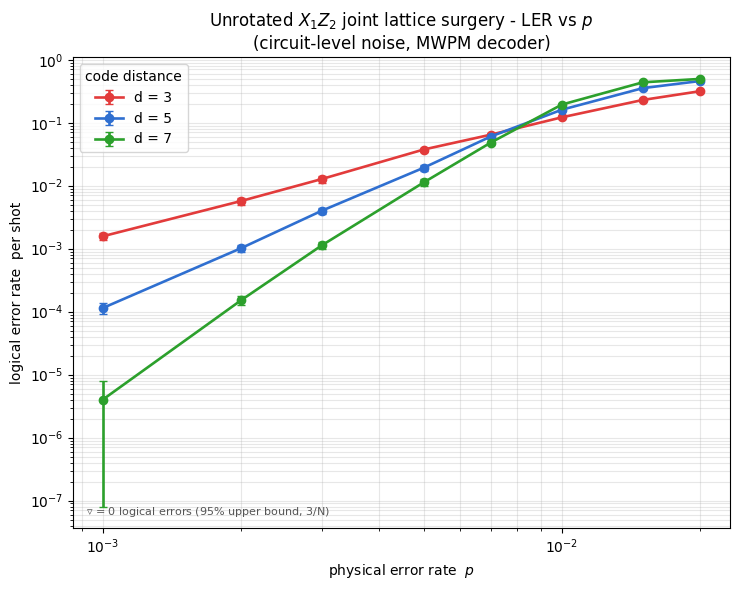

In [30]:
# ---- plot: logical error rate vs physical error rate p (one curve per distance) ----
fig, ax = plt.subplots(figsize=(7.5, 6))
COLORS = {3: '#e23b3b', 5: '#2f6fd0', 7: '#2ca02c'}
for d in DISTANCES:
    r = results[d]
    p_arr = np.array(r['p']); ler = np.array(r['ler']); half = np.array(r['half'])
    errs = np.array(r['errors']); shots = np.array(r['shots'])
    nz = errs > 0
    ax.errorbar(p_arr[nz], ler[nz], yerr=half[nz], marker='o', capsize=3, lw=1.9,
                color=COLORS[d], label=f'd = {d}')
    if (~nz).any():                                  # 0 errors -> 95% upper bound (rule of three, 3/N)
        ax.plot(p_arr[~nz], 3.0 / shots[~nz], marker='v', ls='none', mfc='none', color=COLORS[d])

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('physical error rate  $p$'); ax.set_ylabel('logical error rate  per shot')
ax.set_title('Unrotated $X_1Z_2$ joint lattice surgery - LER vs $p$\n(circuit-level noise, MWPM decoder)')
ax.grid(True, which='both', alpha=0.3); ax.legend(title='code distance')
ax.annotate('$\\triangledown$ = 0 logical errors (95% upper bound, 3/N)', xy=(0.02, 0.02),
            xycoords='axes fraction', fontsize=8, va='bottom', color='#555')
plt.tight_layout(); plt.show()